# Let's Build The Model

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error

# Step - 1: Data loading

In [5]:
df = pd.read_csv("D:\\Veena\\Certificate Program in AI and ML\\Certificate-Program-in-AIML-IIT-Patna\\MODULE 2 - CLASSICAL ML\\Dataset\\cardekho_dataset.csv")
df.head(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


# Step 2: dropping Unwanted and unnecessary columns, for model

In [6]:
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])
print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")


Shape after dropping: (15411, 11)
Remaining columns: ['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [7]:
df

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


# Step 3: Encoding the data

In [8]:
# One-hot encode all categorical columns
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type',
                                  'transmission_type'], drop_first=True)

print(f"Shape after encoding: {df.shape}")
print(f"Sample of new columns: {df.columns}")


Shape after encoding: (15411, 45)
Sample of new columns: Index(['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
       'selling_price', 'brand_BMW', 'brand_Bentley', 'brand_Datsun',
       'brand_Ferrari', 'brand_Force', 'brand_Ford', 'brand_Honda',
       'brand_Hyundai', 'brand_ISUZU', 'brand_Isuzu', 'brand_Jaguar',
       'brand_Jeep', 'brand_Kia', 'brand_Land Rover', 'brand_Lexus',
       'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Maserati',
       'brand_Mercedes-AMG', 'brand_Mercedes-Benz', 'brand_Mini',
       'brand_Nissan', 'brand_Porsche', 'brand_Renault', 'brand_Rolls-Royce',
       'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen',
       'brand_Volvo', 'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG',
       'fuel_type_Petrol', 'transmission_type_Manual'],
      dtype='str')


In [9]:
df.head(10)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,...,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,...,False,False,False,False,False,True,False,False,False,True
5,8,35000,18.90,998,67.10,5,350000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
6,8,40000,20.36,1197,78.90,5,315000,False,False,False,...,False,False,False,False,False,False,False,False,True,True
7,3,17512,20.51,998,67.04,5,410000,False,False,False,...,False,False,False,False,False,False,False,False,True,True
8,2,20000,18.15,998,118.35,5,1050000,False,False,False,...,False,False,False,True,False,False,False,False,True,False
9,4,28321,16.60,1197,85.00,5,511000,False,False,False,...,False,False,False,False,False,False,False,False,True,True


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   vehicle_age                   15411 non-null  int64  
 1   km_driven                     15411 non-null  int64  
 2   mileage                       15411 non-null  float64
 3   engine                        15411 non-null  int64  
 4   max_power                     15411 non-null  float64
 5   seats                         15411 non-null  int64  
 6   selling_price                 15411 non-null  int64  
 7   brand_BMW                     15411 non-null  bool   
 8   brand_Bentley                 15411 non-null  bool   
 9   brand_Datsun                  15411 non-null  bool   
 10  brand_Ferrari                 15411 non-null  bool   
 11  brand_Force                   15411 non-null  bool   
 12  brand_Ford                    15411 non-null  bool   
 13  brand_Honda 

# Step 4: Seperating input as x and output as y

In [11]:
x=df.drop(columns=['selling_price'])
y=df['selling_price']

print(f"shape of x: \n{x.shape}")
print(f"\nshape of y: \n{y.shape}")

shape of x: 
(15411, 44)

shape of y: 
(15411,)


### When to do Scaling - Before split or after Split????

- When we scale the data before the split, we will be hinting the model of how the mean and std deviation of the test data will be. So we should always split the data first and then scale it.
- Another important point is, after splitting we calculate men and std of training data. This will be applied to scale the particular column, of training data. THis is obvious. But the same mean and std will be used to scale the test data as well. We will not calculate the mean and std on test data again for scaling. Because the testing data is completely hidden ir unforeseen by the model. We only have the traing data's statistics. And also we should get the testing data into the traing space be scaling it using training statistics.
- Now when the model sees unforeseen data/future data, agin that data will be scaled using traing statistics. So basically, we are setting our data in the training space of the model. Below is the flow:
New Input -> Scaler (using training mean/std) -> Scaled Input -> Model -> Prediction

# Step 5: Splitting the dataset into train and test.

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print(f"shape of x_train: {x_train.shape}, {x_train.shape[0]/len(x)*100 :.0f}% of data")
print(f"shape of x_test: {x_test.shape}, {x_test.shape[0]/len(x)*100 :.0f}% of data")

shape of x_train: (12328, 44), 80% of data
shape of x_test: (3083, 44), 20% of data


# Step 6: Scaling the training set

In [13]:
numericCols=['vehicle_age','km_driven','mileage','engine','max_power','seats']

scalar = StandardScaler()
#fit will find mean and std, transform will apply the standardization formula on each data point.
#This can be done seperately as well, like .fit(), .transform()
x_train[numericCols]=scalar.fit_transform(x_train[numericCols])

print(f"data after scaling: \n{x_train.head(3)}")
print(f"details of x_train after scaling: \n{x_train.describe()}")

data after scaling: 
       vehicle_age  km_driven   mileage    engine  max_power     seats  \
11210     0.323969   0.349100 -2.050819  1.756765   2.681685 -0.403824   
1347     -1.337798  -1.069394  0.985661 -0.547081  -0.382744 -0.403824   
10363    -1.337798  -1.163564 -0.177042  0.893542   3.296910 -0.403824   

       brand_BMW  brand_Bentley  brand_Datsun  brand_Ferrari  ...  \
11210      False          False         False          False  ...   
1347       False          False         False          False  ...   
10363      False          False         False          False  ...   

       brand_Toyota  brand_Volkswagen  brand_Volvo  seller_type_Individual  \
11210         False             False         True                   False   
1347          False             False        False                    True   
10363         False             False        False                   False   

       seller_type_Trustmark Dealer  fuel_type_Diesel  fuel_type_Electric  \
11210          

# Step 7: Model Training

In [14]:
model = LinearRegression()
#below line is training the model.
model.fit(x_train,y_train)
# m value for every feature(coefficient)
print(f"No.of coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")


No.of coefficients: [-2.27679116e+05 -4.61441160e+04 -1.61215737e+04  7.81262973e+04
  3.35373847e+05  3.61447730e+04  4.05858369e+05  3.66129519e+06
 -7.09797494e+05  3.35712157e+07 -6.84161881e+05 -6.05929376e+05
 -6.34461348e+05 -5.81777427e+05 -5.39248828e+05 -6.72399952e+05
  3.89829810e+05 -3.30328774e+05 -1.88217266e+05  1.37973826e+06
  2.43851701e+06 -3.34953252e+05 -7.57351045e+05 -5.09629233e+05
  3.05324950e+06  1.11758709e-08  2.12192715e+05  5.81734336e+05
 -6.92637218e+05  1.83113118e+06 -6.41815125e+05  1.83478941e+07
 -6.76533456e+05 -8.25722441e+05 -4.17293997e+05 -6.20822305e+05
  1.07324564e+06 -1.20906369e+04 -8.11214717e+04  4.90755661e+04
  2.93031384e+05  2.77714921e+05 -4.11245704e+04 -5.92492214e+04]
Intercept: 1324658.821049799


## Yay!!!! We have created a ML model !!!!

### Now that we have created a mmodel and trained it, how will i know that my model is right? 
- This will be decided on Mean Absolute Error of the model. Meaning, we have y(input data result col). W e will calculate the y`(predicted value by model) by formula y`=m1x1+m2x2+m3x3....+c
- Then we find the absolute difference between the actual val and predicted val. Then we sum and take average. This is known as ***Mean Absolute Error***.

## Creating a baseline model b4 jumping into predictions

In [15]:
import numpy as np

mean_price = y_train.mean()

#Here * is not multiplication it is to repeate the mean_price by len(y_train)
baseline_pred = [mean_price] * len(y_train)
baseline_pred_test = [mean_price] * len(y_test)


print(f"Mean Selling Price (Baseline Prediction): {mean_price:.2f}")
print(f"Baseline MAE over training data: {mean_absolute_error(y_train,baseline_pred):.2f}")
print(f"Baseline MAE over testing data: {mean_absolute_error(y_test,baseline_pred_test):.2f}")


Mean Selling Price (Baseline Prediction): 772120.62
Baseline MAE over training data: 447104.19
Baseline MAE over testing data: 468748.46


# Step 8: Predictions

In [16]:
y_train_pred = model.predict(x_train)
print(f"type of y_train_pred: \n{type(y_train_pred)}")
print(f"y_train_pred: \n{y_train_pred}")


type of y_train_pred: 
<class 'numpy.ndarray'>
y_train_pred: 
[3412193.03734086  538816.57194792 3107972.2792696  ...  315413.96838231
  792625.57941124 1096655.71792075]


# Step 9: Calculate Mean Absolute Error(MAE)

In [17]:
mae_train = mean_absolute_error(y_train,y_train_pred)
print(f"MAE for training data : {mae_train}")

#The training MAE is far better than my baseline MAE.

MAE for training data : 199219.72900407398


# Step 10: Scale the test data

In [18]:
#We are only doing transform not fit, because we again don't want to calculate mean and std of test data. The scalar obj will have the mean and std of train data.
x_test[numericCols] = scalar.transform(x_test[numericCols])
y_test_pred=model.predict(x_test)
mae_test = mean_absolute_error(y_test,y_test_pred)
print(f"MAE for testing data : {mae_test}")
#The training MAE is far better than my baseline MAE, but worse than training MAE.

MAE for testing data : 212761.44410581276


# Effect of Coefficients on Data

In [19]:
coeff_df = pd.DataFrame({
    "Features":x_train.columns,
    "Coefficients":model.coef_
    }
)
coeff_df['Abs_coeff'] = coeff_df['Coefficients'].abs()
coeff_df = coeff_df.sort_values(['Abs_coeff'],ascending=False)
print(f"coeff_df: \n{coeff_df}")
print(f"Top most 15 impactful features")
print("="*65)
for _, row in coeff_df.head(15).iterrows():
    direction="up" if row["Coefficients"] > 0 else "down"
    bar_len = int(row['Abs_coeff'] / coeff_df['Abs_coeff'].max()*30)
    bar="||" * bar_len
    print(f"{direction} {row['Features']:30s} {bar} ({row['Coefficients']:>+12,.0f})")

print(f"\n Intercept : Rs. {model.intercept_:.0f}")    




coeff_df: 
                        Features  Coefficients     Abs_coeff
9                  brand_Ferrari  3.357122e+07  3.357122e+07
31             brand_Rolls-Royce  1.834789e+07  1.834789e+07
7                  brand_Bentley  3.661295e+06  3.661295e+06
24                brand_Maserati  3.053250e+06  3.053250e+06
20                   brand_Lexus  2.438517e+06  2.438517e+06
29                 brand_Porsche  1.831131e+06  1.831131e+06
19              brand_Land Rover  1.379738e+06  1.379738e+06
36                   brand_Volvo  1.073246e+06  1.073246e+06
33                    brand_Tata -8.257224e+05  8.257224e+05
22                brand_Mahindra -7.573510e+05  7.573510e+05
8                   brand_Datsun -7.097975e+05  7.097975e+05
28                  brand_Nissan -6.926372e+05  6.926372e+05
10                   brand_Force -6.841619e+05  6.841619e+05
32                   brand_Skoda -6.765335e+05  6.765335e+05
15                   brand_Isuzu -6.724000e+05  6.724000e+05
30           

# Prediction for one random row in test data

In [20]:
x_test.loc[3334]


vehicle_age                     1.985737
km_driven                       0.413795
mileage                         0.149668
engine                         -0.550917
max_power                      -0.502047
seats                          -0.403824
brand_BMW                          False
brand_Bentley                      False
brand_Datsun                       False
brand_Ferrari                      False
brand_Force                        False
brand_Ford                         False
brand_Honda                        False
brand_Hyundai                       True
brand_ISUZU                        False
brand_Isuzu                        False
brand_Jaguar                       False
brand_Jeep                         False
brand_Kia                          False
brand_Land Rover                   False
brand_Lexus                        False
brand_MG                           False
brand_Mahindra                     False
brand_Maruti                       False
brand_Maserati  

In [21]:
frstIndx = x_test.index[0]
sample_feature = x_test.loc[frstIndx]

print(f"type(sample_feature): {type(sample_feature)}")
print(f"sample_feature: {sample_feature}")

sample_result = y_test.loc[frstIndx]
print(f"sample_result: {sample_result}")

sample_predict = model.predict(x_test.loc[[frstIndx]])

print(f"sample_predict: {sample_predict}")
print(f"actual_value: {y_test.loc[frstIndx]}")



type(sample_feature): <class 'pandas.Series'>
sample_feature: vehicle_age                     1.985737
km_driven                       0.413795
mileage                         0.149668
engine                         -0.550917
max_power                      -0.502047
seats                          -0.403824
brand_BMW                          False
brand_Bentley                      False
brand_Datsun                       False
brand_Ferrari                      False
brand_Force                        False
brand_Ford                         False
brand_Honda                        False
brand_Hyundai                       True
brand_ISUZU                        False
brand_Isuzu                        False
brand_Jaguar                       False
brand_Jeep                         False
brand_Kia                          False
brand_Land Rover                   False
brand_Lexus                        False
brand_MG                           False
brand_Mahindra                     F

## Manual calculation of the target column using formula

In [22]:
type(model.coef_)

numpy.ndarray

In [23]:
#formula = [val(i)*coeff(i)] + intercept

ManualPred = 0
for feature,val in sample_feature.items():
    coeff=model.coef_[list(x_train.columns).index(feature)]
    print(f"Feature: {feature}, coeffecient value: {coeff}, feature value: {val}")
    ManualPred = ManualPred + (coeff * val)

print(f"Manual Calculated value: {ManualPred+model.intercept_}")


Feature: vehicle_age, coeffecient value: -227679.11587518532, feature value: 1.9857368532491522
Feature: km_driven, coeffecient value: -46144.116023431256, feature value: 0.4137954453676014
Feature: mileage, coeffecient value: -16121.573709104463, feature value: 0.14966790175177855
Feature: engine, coeffecient value: 78126.29726953666, feature value: -0.5509174225989446
Feature: max_power, coeffecient value: 335373.84695451736, feature value: -0.5020465790486297
Feature: seats, coeffecient value: 36144.7730434135, feature value: -0.40382371071387335
Feature: brand_BMW, coeffecient value: 405858.36913186533, feature value: False
Feature: brand_Bentley, coeffecient value: 3661295.1869869917, feature value: False
Feature: brand_Datsun, coeffecient value: -709797.4940395997, feature value: False
Feature: brand_Ferrari, coeffecient value: 33571215.66884785, feature value: False
Feature: brand_Force, coeffecient value: -684161.8808380417, feature value: False
Feature: brand_Ford, coeffecient

### Taking the sample feature, we did it in both ways, manually and using model. Both gave us the same values.

## WHat if my data when plotted doesn't give a stright line??

- What if my data instead of plotting as a straight line, gives us a curve?? It is not guaranteed that my data will always give straight. In such situations, even, how many ever straigh lines are drawn by model, none of them will match with my actual data.
- This is the limitation of Linear Reggression. It always assumes that the data will always be in a straight line.
- In such cases we can use XGBoost, it as another algo under Regression technique.
- So we need to be cautious while choosing the model or algo, w.r.t the nature of data. 


## Rooted Mean Squared Error
- 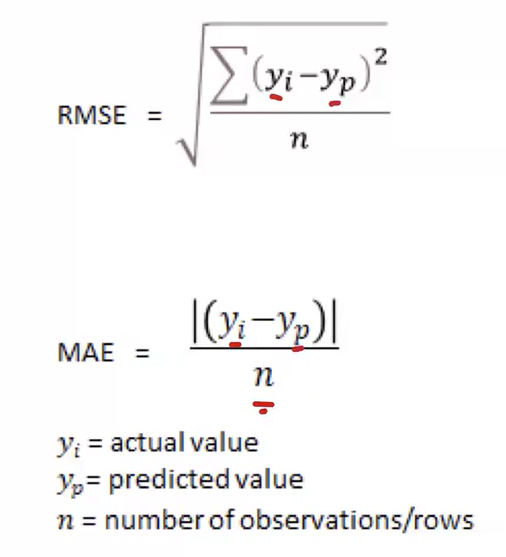
- The MAE should be in smaller range. 
- We want the points that are far away from the best-fit line to be optimised. 
- When to use: When u try to care that the model has to predict for the extreame points(not outliers) as well. Like the extreme points should also be considered, in validating a model.
- RMSE is better tahn MAE.
- But when we have outliers, we need to consider ***R squared***.
- Without seeing data, when we are given with MAE, will we know that if the mnodel has done a good job or not. But R sqaured will give a value by which we can judge.
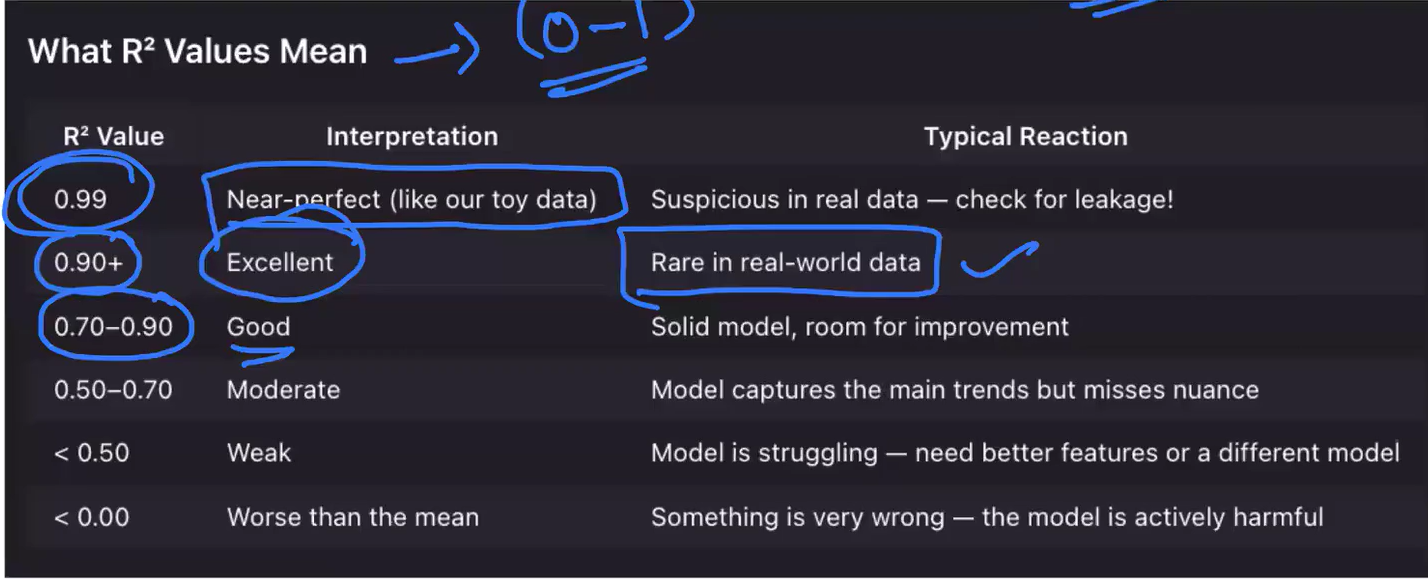

# Calculating r square for the training set of our model

In [24]:
from sklearn.metrics import r2_score

training_r2 = r2_score(y_train,y_train_pred)
print(f"training_r2: {training_r2}")

training_r2: 0.8015753782439603


In [25]:
testing_r2 = r2_score(y_test,y_test_pred)
print(f"testing_r2: {testing_r2}")

testing_r2: 0.7359948378848242


## We can improve the score by using different algo's and refining the dataset more.

In [26]:
print(f"==================METRICS OF TRAINING SET ==================")
print(f"MAE:{mae_train:.2f}")
print(f"r2: {training_r2:.2f}")
print(f"\n==================METRICS OF TESTING SET ==================")
print(f"MAE:{mae_test:.2f}")        
print(f"r2: {testing_r2:.2f}")

print(f"=====================TEST TRAIN GAP====================")
#If gap = +ve --> overfitting, gap = -ve --> underfitting, gap = 0 --> good fit
gap=training_r2-testing_r2
print(f"Gap: {gap:.2f}, the model is {'overfitting' if gap > 0 else 'underfitting' if gap < 0 else 'good fit'}")

==================METRICS OF TRAINING SET ==================
MAE:199219.73
r2: 0.80

==================METRICS OF TESTING SET ==================
MAE:212761.44
r2: 0.74
=====================TEST TRAIN GAP====================
Gap: 0.07, the model is overfitting


### The above model is not that worse, but decent. Now Let's try with another model **RIDGE**

In [27]:
ridgeModel = Ridge(alpha=1.0)
ridgeModel.fit(x_train, y_train)

yTrainPrediction = ridgeModel.predict(x_train)
yTestPrediction = ridgeModel.predict(x_test)


trainMAE = mean_absolute_error(y_train,yTrainPrediction)
testMAE=mean_absolute_error(y_test,yTestPrediction)

r2Train = r2_score(y_train,yTrainPrediction)
r2Test = r2_score(y_test,yTestPrediction)

print('='*35)
print(f"Train MAE: {trainMAE}")
print(f"Test MAE: {testMAE}")
print(f"Train R2: {r2Train}")
print(f"Test R2: {r2Test}")
print("="*35)
gap = r2Train - r2Test

print(f"Gap: {gap} {'Overfitting' if gap >0 else 'Underfitting' if gap < 0 else 'Goodfit'}")

Train MAE: 210894.24013645938
Test MAE: 220956.1599669607
Train R2: 0.764242885997274
Test R2: 0.7365715780232369
Gap: 0.02767130797403705 Overfitting


### Our next task is to find the best Alpha. For that we will consider a set of alphas and run the model creation in a loop.

In [28]:
alphas=[0.10,0.5,1.05,1.78,3.89,5.78,20,30,50,70,100,500]

print(f"{'Alpha':>10s} | {'Train MAE':>10s} | {'Test MAE':>10s} | {'Train R2':>10s} | {'Test R2':>10s} | {'Gap':>10s} | {'Fit Type':>12s}")

for a in alphas:
    print("="*80)
    print(f"====================Alpha: {a}=====================")
    ridgeModel = Ridge(alpha=a)
    ridgeModel.fit(x_train, y_train)
    ridgeModel.fit(x_train, y_train)
    
    
    yTrainPrediction = ridgeModel.predict(x_train)
    yTrainPrediction = ridgeModel.predict(x_train)
    yTestPrediction = ridgeModel.predict(x_test)
    yTestPrediction = ridgeModel.predict(x_test)
    
    
    trainMAE = mean_absolute_error(y_train,yTrainPrediction)
    testMAE=mean_absolute_error(y_test,yTestPrediction)
    
    r2Train = r2_score(y_train,yTrainPrediction)
    r2Test = r2_score(y_test,yTestPrediction)
    
    print('='*35)
    print(f"Train MAE: {trainMAE}")
    print(f"Test MAE: {testMAE}")
    print(f"Train R2: {r2Train}")
    print(f"Test R2: {r2Test}")
    print("="*35)
    gap = r2Train - r2Test
    
    print(f"Gap: {gap} {'Overfitting' if gap >0 else 'Underfitting' if gap < 0 else     'Goodfit'}")

     Alpha |  Train MAE |   Test MAE |   Train R2 |    Test R2 |        Gap |     Fit Type
====================Alpha: 0.1=====================
Train MAE: 200942.21809674238
Test MAE: 213833.91838937165
Train R2: 0.8002645991170925
Test R2: 0.736758138164779
Gap: 0.06350646095231349 Overfitting
====================Alpha: 0.5=====================
Train MAE: 206443.47179377443
Test MAE: 217621.462605119
Train R2: 0.7845834986879356
Test R2: 0.7373704000675306
Gap: 0.047213098620405014 Overfitting
====================Alpha: 1.05=====================
Train MAE: 211246.2869082177
Test MAE: 221228.92600991105
Train R2: 0.7624653865817678
Test R2: 0.7364704079118778
Gap: 0.02599497866988998 Overfitting
====================Alpha: 1.78=====================
Train MAE: 215245.8290567622
Test MAE: 224418.38273037985
Train R2: 0.7414794336187969
Test R2: 0.7349789513223444
Gap: 0.006500482296452503 Overfitting
====================Alpha: 3.89=====================
Train MAE: 221032.05766309946
Test MA

### Iteration-3, Now we found out that my model changes from overfitting to underfitting, b/w 1.78 to 3.79. So my good fit model lies between it.

In [29]:
alphas=[1.78,1.80,2.17,2.58,2.78,3.00,3.51,3.89]

print(f"{'Alpha':>10s} | {'Train MAE':>10s} | {'Test MAE':>10s} | {'Train R2':>10s} | {'Test R2':>10s} | {'Gap':>10s} | {'Fit Type':>12s}")

for a in alphas:
    print("="*80)
    print(f"====================Alpha: {a}=====================")
    ridgeModel = Ridge(alpha=a)
    ridgeModel.fit(x_train, y_train)
    ridgeModel.fit(x_train, y_train)
    
    
    yTrainPrediction = ridgeModel.predict(x_train)
    yTrainPrediction = ridgeModel.predict(x_train)
    yTestPrediction = ridgeModel.predict(x_test)
    yTestPrediction = ridgeModel.predict(x_test)
    
    
    trainMAE = mean_absolute_error(y_train,yTrainPrediction)
    testMAE=mean_absolute_error(y_test,yTestPrediction)
    
    r2Train = r2_score(y_train,yTrainPrediction)
    r2Test = r2_score(y_test,yTestPrediction)
    
    print('='*35)
    print(f"Train MAE: {trainMAE}")
    print(f"Test MAE: {testMAE}")
    print(f"Train R2: {r2Train}")
    print(f"Test R2: {r2Test}")
    print("="*35)
    gap = r2Train - r2Test
    
    print(f"Gap: {gap} {'Overfitting' if gap >0 else 'Underfitting' if gap < 0 else     'Goodfit'}")

     Alpha |  Train MAE |   Test MAE |   Train R2 |    Test R2 |        Gap |     Fit Type
====================Alpha: 1.78=====================


Train MAE: 215245.8290567622
Test MAE: 224418.38273037985
Train R2: 0.7414794336187969
Test R2: 0.7349789513223444
Gap: 0.006500482296452503 Overfitting
====================Alpha: 1.8=====================
Train MAE: 215331.76478214213
Test MAE: 224489.08142086116
Train R2: 0.7410154446984946
Test R2: 0.734939695827653
Gap: 0.006075748870841613 Overfitting
====================Alpha: 2.17=====================
Train MAE: 216761.5113226864
Test MAE: 225685.89863601234
Train R2: 0.7332500280086669
Test R2: 0.7342373824454496
Gap: -0.0009873544367826614 Underfitting
====================Alpha: 2.58=====================
Train MAE: 218060.86865298578
Test MAE: 226790.17456511685
Train R2: 0.7261532430214661
Test R2: 0.7335116006644087
Gap: -0.00735835764294257 Underfitting
====================Alpha: 2.78=====================
Train MAE: 218613.0362105226
Test MAE: 227260.81730432744
Train R2: 0.7231496298600015
Test R2: 0.7331761650269215
Gap: -0.010026535166919981 Underfitting
=================

### Iteration - 4

In [30]:
alphas=[1.80,1.90,1.98,2.02,2.08,2.17]

print(f"{'Alpha':>10s} | {'Train MAE':>10s} | {'Test MAE':>10s} | {'Train R2':>10s} | {'Test R2':>10s} | {'Gap':>10s} | {'Fit Type':>12s}")

for a in alphas:
    print("="*80)
    print(f"====================Alpha: {a}=====================")
    ridgeModel = Ridge(alpha=a)
    ridgeModel.fit(x_train, y_train)
    ridgeModel.fit(x_train, y_train)
    
    
    yTrainPrediction = ridgeModel.predict(x_train)
    yTrainPrediction = ridgeModel.predict(x_train)
    yTestPrediction = ridgeModel.predict(x_test)
    yTestPrediction = ridgeModel.predict(x_test)
    
    
    trainMAE = mean_absolute_error(y_train,yTrainPrediction)
    testMAE=mean_absolute_error(y_test,yTestPrediction)
    
    r2Train = r2_score(y_train,yTrainPrediction)
    r2Test = r2_score(y_test,yTestPrediction)
    
    print('='*35)
    print(f"Train MAE: {trainMAE}")
    print(f"Test MAE: {testMAE}")
    print(f"Train R2: {r2Train}")
    print(f"Test R2: {r2Test}")
    print("="*35)
    gap = r2Train - r2Test
    
    print(f"Gap: {gap} {'Overfitting' if gap >0 else 'Underfitting' if gap < 0 else     'Goodfit'}")

     Alpha |  Train MAE |   Test MAE |   Train R2 |    Test R2 |        Gap |     Fit Type
====================Alpha: 1.8=====================
Train MAE: 215331.76478214213
Test MAE: 224489.08142086116
Train R2: 0.7410154446984946
Test R2: 0.734939695827653
Gap: 0.006075748870841613 Overfitting
====================Alpha: 1.9=====================
Train MAE: 215746.03167906695
Test MAE: 224833.97751454255
Train R2: 0.738767950665251
Test R2: 0.7347453764043158
Gap: 0.004022574260935219 Overfitting
====================Alpha: 1.98=====================
Train MAE: 216061.81956776086
Test MAE: 225098.11226660846
Train R2: 0.7370528533396268
Test R2: 0.7345923109215038
Gap: 0.0024605424181229907 Overfitting
====================Alpha: 2.02=====================
Train MAE: 216215.0926679727
Test MAE: 225226.241728295
Train R2: 0.7362215188186902
Test R2: 0.7345165829721017
Gap: 0.0017049358465885955 Overfitting
====================Alpha: 2.08=====================
Train MAE: 216438.87736824807
Tes

### Iteration - 5

In [31]:
alphas = [1.90, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98]

print(f"{'Alpha':>10s} | {'Train MAE':>10s} | {'Test MAE':>10s} | {'Train R2':>10s} | {'Test R2':>10s} | {'Gap':>10s} | {'Fit Type':>12s}")

r2_values=[]
mae_values=[]


for a in alphas:
    print("="*80)
    print(f"====================Alpha: {a}=====================")
    ridgeModel = Ridge(alpha=a)
    ridgeModel.fit(x_train, y_train)
    
    
    yTrainPrediction = ridgeModel.predict(x_train)
    yTestPrediction = ridgeModel.predict(x_test)
    
    
    trainMAE = mean_absolute_error(y_train,yTrainPrediction)
    testMAE=mean_absolute_error(y_test,yTestPrediction)
    mae_values.append((trainMAE, testMAE))

    r2Train = r2_score(y_train,yTrainPrediction)
    r2Test = r2_score(y_test,yTestPrediction)
    r2_values.append((r2Train, r2Test))
    
    print('='*35)
    print(f"Train MAE: {trainMAE}")
    print(f"Test MAE: {testMAE}")
    print(f"Train R2: {r2Train}")
    print(f"Test R2: {r2Test}")
    print("="*35)
    gap = r2Train - r2Test
    
    print(f"Gap: {gap} {'Overfitting' if gap >0 else 'Underfitting' if gap < 0 else     'Goodfit'}")

     Alpha |  Train MAE |   Test MAE |   Train R2 |    Test R2 |        Gap |     Fit Type
====================Alpha: 1.9=====================
Train MAE: 215746.03167906695
Test MAE: 224833.97751454255
Train R2: 0.738767950665251
Test R2: 0.7347453764043158
Gap: 0.004022574260935219 Overfitting
====================Alpha: 1.91=====================
Train MAE: 215786.0993519248
Test MAE: 224867.6358468029
Train R2: 0.7385496392990852
Test R2: 0.7347261262397562
Gap: 0.0038235130593290423 Overfitting
====================Alpha: 1.92=====================
Train MAE: 215826.02020841723
Test MAE: 224901.0966890409
Train R2: 0.7383324652206515
Test R2: 0.7347069094109437
Gap: 0.0036255558097078033 Overfitting
====================Alpha: 1.93=====================
Train MAE: 215865.72440596155
Test MAE: 224934.38096369774
Train R2: 0.7381164203108269
Test R2: 0.7346877259683995
Gap: 0.0034286943424274297 Overfitting
====================Alpha: 1.94=====================
Train MAE: 215905.2981173035
T

In [32]:
print(f"r2_values: {r2_values}")
print(f"mae_values: {mae_values}")

r2_values: [(0.738767950665251, 0.7347453764043158), (0.7385496392990852, 0.7347261262397562), (0.7383324652206515, 0.7347069094109437), (0.7381164203108269, 0.7346877259683995), (0.7379014965108597, 0.7346685759568299), (0.7376876858222359, 0.7346494594153183), (0.7374749803065311, 0.7346303763775126), (0.737263372085246, 0.7346113268718043), (0.7370528533396268, 0.7345923109215038)]
mae_values: [(215746.03167906695, 224833.97751454255), (215786.0993519248, 224867.6358468029), (215826.02020841723, 224901.0966890409), (215865.72440596155, 224934.38096369774), (215905.2981173035, 224967.46243317614), (215944.7487090489, 225000.3474264165), (215983.988991508, 225033.0541628907), (216023.00971473684, 225065.6473649673), (216061.81956776086, 225098.11226660846)]


### Plotting the R2 and MAE values

Best Alpha: 1.9 with Test R²: 0.7347


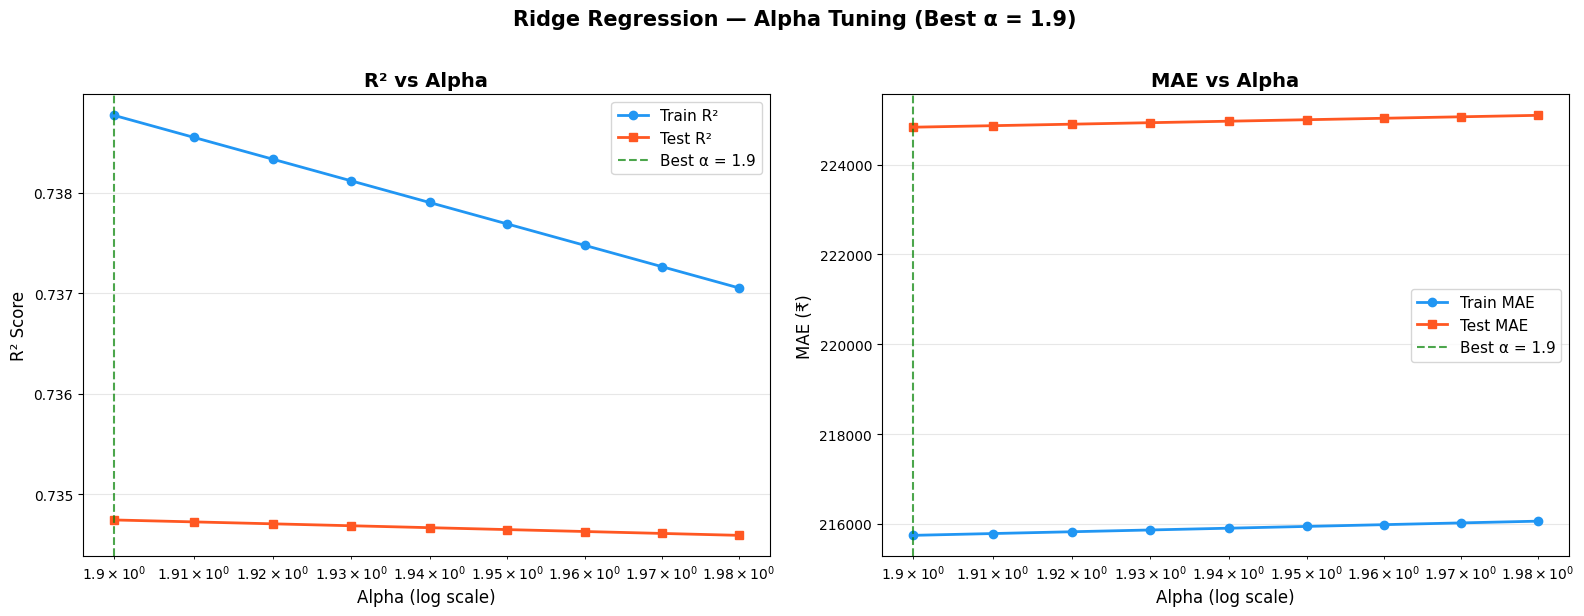

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# The below zip will unzip the list of tuples into two separate lists, one for training R² and one for testing R².
r2_train,r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)

bestAplha_indx = np.argmax(r2_test)
bestAlpha = alphas[bestAplha_indx]

print(f"Best Alpha: {bestAlpha} with Test R²: {r2_test[bestAplha_indx]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── R² Plot ──
axes[0].plot(alphas, r2_train, 'o-', label='Train R²', color='#2196F3', linewidth=2)
axes[0].plot(alphas, r2_test, 's-', label='Test R²', color='#FF5722', linewidth=2)
axes[0].axvline(bestAlpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {bestAlpha}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² vs Alpha', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── MAE Plot ──
axes[1].plot(alphas, mae_train, 'o-', label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(alphas, mae_test, 's-', label='Test MAE', color='#FF5722', linewidth=2)
axes[1].axvline(bestAlpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {bestAlpha}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('MAE (₹)', fontsize=12)
axes[1].set_title('MAE vs Alpha', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Ridge Regression — Alpha Tuning (Best α = {bestAlpha})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## LASSO MODEL

In [34]:
alphas = [1.90, 1.91, 1.92, 1.93, 1.94, 1.95, 1.96, 1.97, 1.98]

print(f"{'Alpha':>10s} | {'Train MAE':>10s} | {'Test MAE':>10s} | {'Train R2':>10s} | {'Test R2':>10s} | {'Gap':>10s} | {'Fit Type':>12s}")

r2_values=[]
mae_values=[]


for a in alphas:
    print("="*80)
    print(f"====================Alpha: {a}=====================")
    lassoModel = Lasso(alpha=a)
    lassoModel.fit(x_train, y_train)
    
    
    yTrainPrediction = lassoModel.predict(x_train)
    yTestPrediction = lassoModel.predict(x_test)
    
    
    trainMAE = mean_absolute_error(y_train,yTrainPrediction)
    testMAE=mean_absolute_error(y_test,yTestPrediction)
    mae_values.append((trainMAE, testMAE))

    r2Train = r2_score(y_train,yTrainPrediction)
    r2Test = r2_score(y_test,yTestPrediction)
    r2_values.append((r2Train, r2Test))
    
    print('='*35)
    print(f"Train MAE: {trainMAE}")
    print(f"Test MAE: {testMAE}")
    print(f"Train R2: {r2Train}")
    print(f"Test R2: {r2Test}")
    print("="*35)
    gap = r2Train - r2Test
    
    print(f"Gap: {gap} {'Overfitting' if gap >0 else 'Underfitting' if gap < 0 else     'Goodfit'}")

     Alpha |  Train MAE |   Test MAE |   Train R2 |    Test R2 |        Gap |     Fit Type
====================Alpha: 1.9=====================
Train MAE: 199242.96192821235
Test MAE: 212766.26582470041
Train R2: 0.8015749769109772
Test R2: 0.7360161315209452
Gap: 0.06555884539003198 Overfitting
====================Alpha: 1.91=====================
Train MAE: 199243.09080797713
Test MAE: 212766.2929012823
Train R2: 0.8015749726802806
Test R2: 0.7360162418758559
Gap: 0.06555873080442465 Overfitting
====================Alpha: 1.92=====================
Train MAE: 199243.21968774198
Test MAE: 212766.31997786424
Train R2: 0.8015749684274013
Test R2: 0.7360163522192786
Gap: 0.06555861620812264 Overfitting
====================Alpha: 1.93=====================
Train MAE: 199243.3482587178
Test MAE: 212766.34548816533
Train R2: 0.8015749641282072
Test R2: 0.7360164654991738
Gap: 0.0655584986290334 Overfitting
====================Alpha: 1.94=====================
Train MAE: 199243.47713849175
Test M

### Plotting R2 and MAE values.

Best Alpha: 1.98 with Test R²: 0.7360


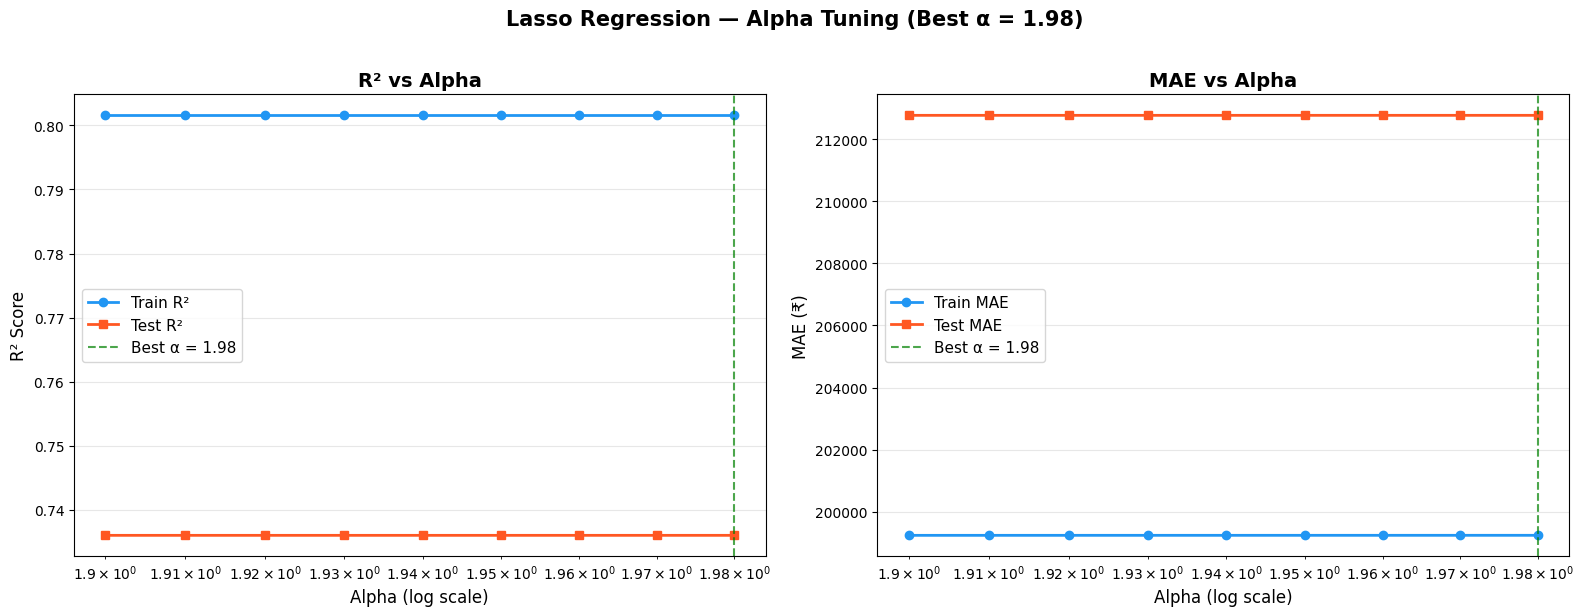

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# The below zip will unzip the list of tuples into two separate lists, one for training R² and one for testing R².
r2_train,r2_test = zip(*r2_values)
mae_train, mae_test = zip(*mae_values)

bestAplha_indx = np.argmax(r2_test)
bestAlpha = alphas[bestAplha_indx]

print(f"Best Alpha: {bestAlpha} with Test R²: {r2_test[bestAplha_indx]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── R² Plot ──
axes[0].plot(alphas, r2_train, 'o-', label='Train R²', color='#2196F3', linewidth=2)
axes[0].plot(alphas, r2_test, 's-', label='Test R²', color='#FF5722', linewidth=2)
axes[0].axvline(bestAlpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {bestAlpha}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² vs Alpha', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── MAE Plot ──
axes[1].plot(alphas, mae_train, 'o-', label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(alphas, mae_test, 's-', label='Test MAE', color='#FF5722', linewidth=2)
axes[1].axvline(bestAlpha, color='green', linestyle='--', alpha=0.7, label=f'Best α = {bestAlpha}')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('MAE (₹)', fontsize=12)
axes[1].set_title('MAE vs Alpha', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Lasso Regression — Alpha Tuning (Best α = {bestAlpha})', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## TRAINING THE BEST MODEL

In [36]:
bestRidgeModel = Ridge(alpha=1.98)
bestRidgeModel.fit(x_train,y_train)

models={
    'Plain Model':model,
    f"Ridge (α={bestAlpha})":bestRidgeModel

}

for name, mdl in models.items():
    print(f"Prediction starts....... with model:{mdl}")
    yTrainPrediction = mdl.predict(x_train)
    yTestPrediction = mdl.predict(x_test)

    print(f"..........Evaluation scores and error of model.....{mdl}")
    trainMAE = mean_absolute_error(y_train,yTrainPrediction)
    testMAE=mean_absolute_error(y_test,yTestPrediction)
    train_r2 = r2_score(y_train, yTrainPrediction)
    test_r2 = r2_score(y_test,yTestPrediction)
    print(f"\nModel: {mdl}")
    print("-" * 45)
    print(f"{'Metric':<15}{'Training':<15}{'Testing':<15}")
    print("-" * 45)
    print(f"{'MAE':<15}{trainMAE:<15.2f}{testMAE:<15.2f}")
    print(f"{'R2':<15}{train_r2:<15.4f}{test_r2:<15.4f}")
    print("-" * 45)






Prediction starts....... with model:LinearRegression()
..........Evaluation scores and error of model.....LinearRegression()

Model: LinearRegression()
---------------------------------------------
Metric         Training       Testing        
---------------------------------------------
MAE            199219.73      212761.44      
R2             0.8016         0.7360         
---------------------------------------------
Prediction starts....... with model:Ridge(alpha=1.98)
..........Evaluation scores and error of model.....Ridge(alpha=1.98)

Model: Ridge(alpha=1.98)
---------------------------------------------
Metric         Training       Testing        
---------------------------------------------
MAE            216061.82      225098.11      
R2             0.7371         0.7346         
---------------------------------------------


In [37]:
coeffComparisionDF = pd.DataFrame({
    "Features": x_train.columns,
    "OLS": model.coef_,
    "Ridge": bestRidgeModel.coef_
})

print(f"coeffComparisionDF: \n{display(coeffComparisionDF)}")

,Features,OLS,Ridge
0,vehicle_age,-2.276791e+05,-2.180933e+05
1,km_driven,-4.614412e+04,-4.698201e+04
2,mileage,-1.612157e+04,1.147283e+04
3,engine,7.812630e+04,8.530773e+04
4,max_power,3.353738e+05,4.660229e+05
5,seats,3.614477e+04,1.378199e+04
6,brand_BMW,4.058584e+05,1.244324e+05
7,brand_Bentley,3.661295e+06,1.289368e+06
8,brand_Datsun,-7.097975e+05,-6.100494e+05
9,brand_Ferrari,3.357122e+07,1.077006e+07


coeffComparisionDF: 
None


## Entire Pipeline of ML

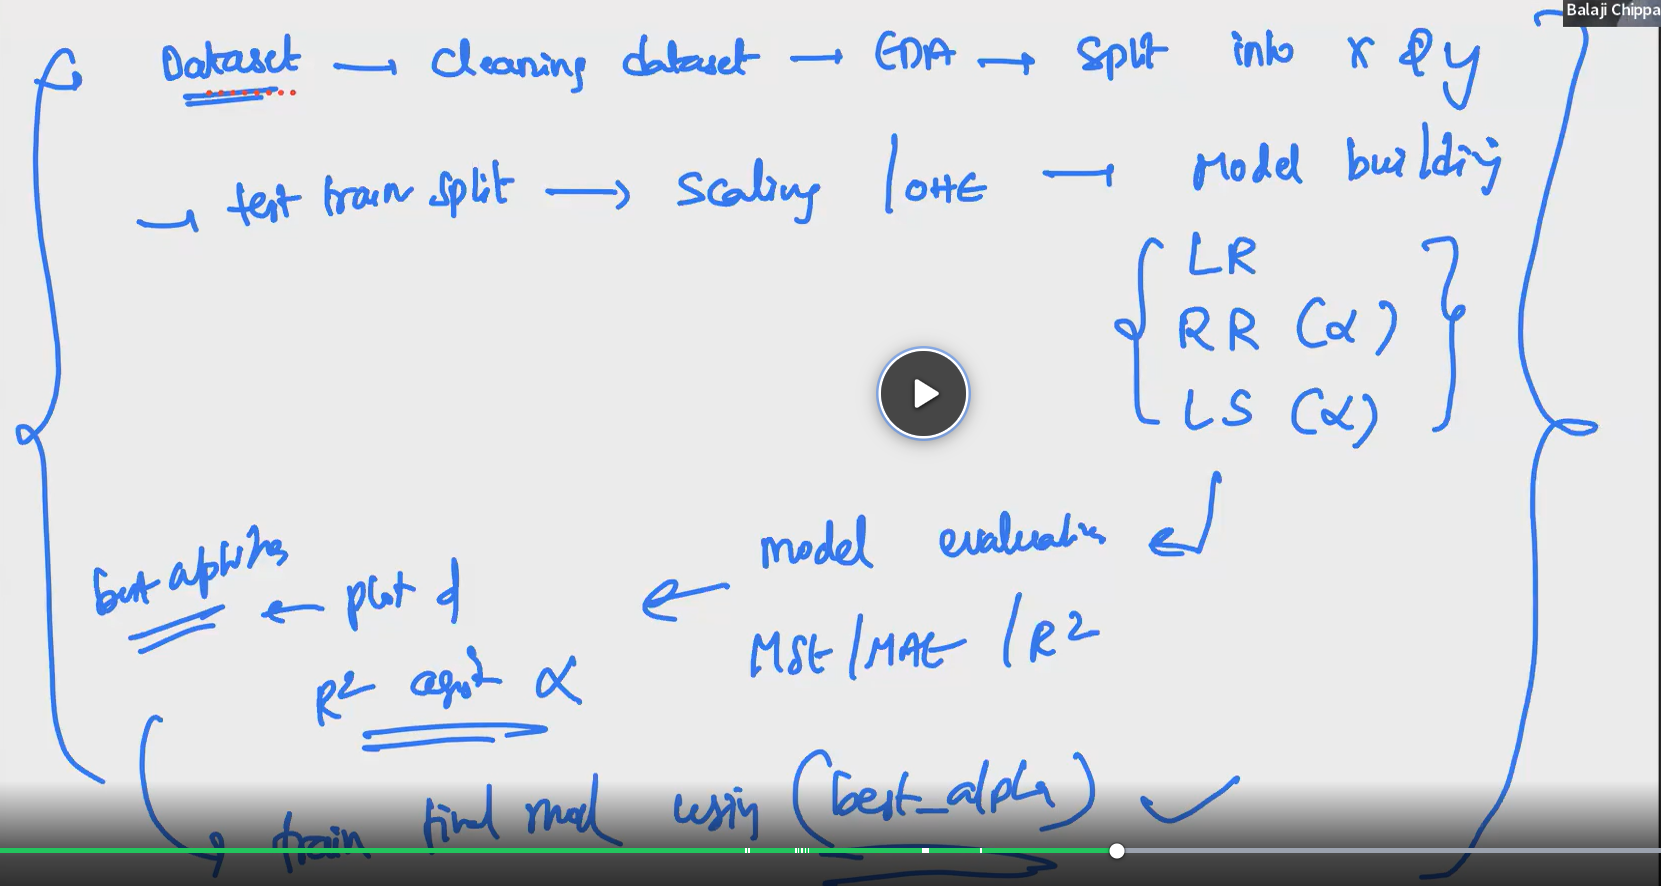

## Can we trust the score just with the first split of train and test, with random_state =42

In [40]:
mae_score=[]

for i in range(0,10):
    #print(f"Iteration...{i}")
    xTr,xTs,yTr,yTs = train_test_split(x,y,test_size=0.2,random_state=i)
    sc = StandardScaler()
    xTr[numericCols] = sc.fit_transform(xTr[numericCols])
    xTs[numericCols] = sc.transform(xTs[numericCols])

    LRmodel = LinearRegression()
    LRmodel.fit(xTr,yTr)

    mae = mean_absolute_error(yTs,LRmodel.predict(xTs))
    print(f"MAE of testing data for split {i}: {mae:.2f}")
    mae_score.append(mae)

#print(f"MAE scores after 10 iterations: {mae_score}")
print(f"MAE scores ranging from {min(mae_score):.2f} to {max(mae_score):.2f}")
print(f"MAE is changing on an average of {np.mean(mae_score):.2f}")





MAE of testing data for split 0: 203168.20
MAE of testing data for split 1: 204367.66
MAE of testing data for split 2: 198994.63
MAE of testing data for split 3: 201127.37
MAE of testing data for split 4: 207461.62
MAE of testing data for split 5: 203116.73
MAE of testing data for split 6: 209605.23
MAE of testing data for split 7: 209054.11
MAE of testing data for split 8: 210801.81
MAE of testing data for split 9: 205982.66
MAE scores ranging from 198994.63 to 210801.81
MAE is changing on an average of 205368.00


## Validation Split:::
- 80% of data - Traing
   - 80 % of traing split
   - 20 % validation split(for user testing)
- 20% testing split   

In [ ]:
print(f"len(x): {len(x)}, len(y): {len(y)}")
xTrain,xTest,yTrain,yTest = train_test_split(x,y,test_size=0.2,random_state=42)
print(f"len(xTrain): {len(xTrain)}, len(xTest): {len(xTest)}")
xTrain,xVal,yTrain,yVal = train_test_split(xTrain,yTrain,test_size=0.2,random_state=42)
print(f"len(xTrain): {len(xTrain)}, len(xVal): {len(xVal)}")


len(x): 15411, len(y): 15411
len(xTrain): 12328, len(xTest): 3083
len(xTrain): 9862, len(xVal): 2466


In [42]:
valModel = LinearRegression()

valModel.fit(xTrain,yTrain)
for name, xSet,ySet in [('Training',xTrain,yTrain),
                       ('Validation',xVal,yVal),
                       ('Testing',xTest,yTest)]:
    yPred = valModel.predict(xSet)

    mae=mean_absolute_error(ySet,yPred)
    r2Score = r2_score(ySet,yPred)

    print(f"{name} MAE: {mae:.2f}, R²: {r2Score:.4f}")


Training MAE: 198840.17, R²: 0.7750
Validation MAE: 214754.63, R²: 0.4889
Testing MAE: 212708.38, R²: 0.7353


#### The validation r2 is small, because, the data set size is very small and the proportion of set sent for validation is very small. So, the model didn't get much exposure for user testing.